superstore-dashboard/
│
├── data/
│   ├── raw/                    # Original downloaded CSV, never touched
│   └── processed/              # Cleaned data output from your pipeline
│
├── notebooks/
│   └── 01_exploration.ipynb    # Initial EDA, understanding the data
│
├── src/
│   ├── __init__.py
│   ├── ingest.py               # Load raw data into SQLite
│   ├── clean.py                # Cleaning & transformation logic
│   └── features.py             # Feature engineering (profit margin, MoM growth etc.)
│
├── dashboard/
│   ├── app.py                  # Main Dash app entry point
│   ├── layout.py               # UI layout (tabs, filters, cards)
│   └── callbacks.py            # Interactivity logic (filter → chart updates)
│
├── database/
│   └── superstore.db           # SQLite database (git-ignored)
│
├── tests/
│   └── test_clean.py           # Basic unit tests for your cleaning functions
│
├── .gitignore
├── requirements.txt
└── README.md                   # Project description, screenshots, how to run

Step 1 — Setup & Data Ingestion

Download the Superstore CSV, set up your repo and virtual environment, write ingest.py to load the raw CSV into a SQLite database. This makes the project feel like a real pipeline rather than just a notebook.
Step 2 — EDA in a Notebook

In 01_exploration.ipynb, explore the data: check nulls, data types, distributions, outliers. Answer questions like which region is most profitable? and which product category has the worst margins? This shapes what goes in your dashboard.
Step 3 — Data Cleaning & Feature Engineering

Write clean.py to handle types (dates, numeric columns), duplicates and nulls. Then write features.py to add derived columns like profit margin (%), month-over-month growth, and customer segment metrics. Output a clean table back to SQLite.
Step 4 — Build the Dashboard

This is the main event. Build in Dash with 3 views:

Overview — KPI cards (total revenue, profit, orders, avg. discount) + trend line over time
Product Analysis — best/worst performing categories and sub-categories
Regional Analysis — breakdown by region/state with a bar or map chart

Add a date range filter and category dropdown that update all charts simultaneously via callbacks.
Step 5 — Forecasting (optional but impressive)

Use Facebook Prophet or statsmodels to add a simple 90-day sales forecast. Display it as an additional chart in the Overview tab.
Step 6 — Testing & Code Quality

Write a few unit tests in tests/ for your cleaning functions. This is a small step but stands out heavily on a portfolio — most students skip it.
Step 7 — README & Polish

Write a strong README with a project description, a screenshot of the dashboard, setup instructions, and key insights you found. This is what a recruiter actually reads.

## 0. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

In [3]:
df = pd.read_csv("../data/raw/superstore.csv", encoding="latin1").set_index("Row ID")

numeric_cols = ["Sales", "Profit", "Quantity", "Discount"]
categorical_cols = ["Category", "Sub-Category", "Region", "Segment", "Ship Mode"]

Check data types

In [4]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Row ID,,,,,,,,,,,,,,,,,,,,
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9994
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Order Date     9994 non-null   object 
 2   Ship Date      9994 non-null   object 
 3   Ship Mode      9994 non-null   object 
 4   Customer ID    9994 non-null   object 
 5   Customer Name  9994 non-null   object 
 6   Segment        9994 non-null   object 
 7   Country        9994 non-null   object 
 8   City           9994 non-null   object 
 9   State          9994 non-null   object 
 10  Postal Code    9994 non-null   int64  
 11  Region         9994 non-null   object 
 12  Product ID     9994 non-null   object 
 13  Category       9994 non-null   object 
 14  Sub-Category   9994 non-null   object 
 15  Product Name   9994 non-null   object 
 16  Sales          9994 non-null   float64
 17  Quantity       9994 non-null   int64  
 18  Discount     

Check Nulls

In [6]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Check distributions

In [7]:
df[numeric_cols].describe()

,Sales,Profit,Quantity,Discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


Numerical columns

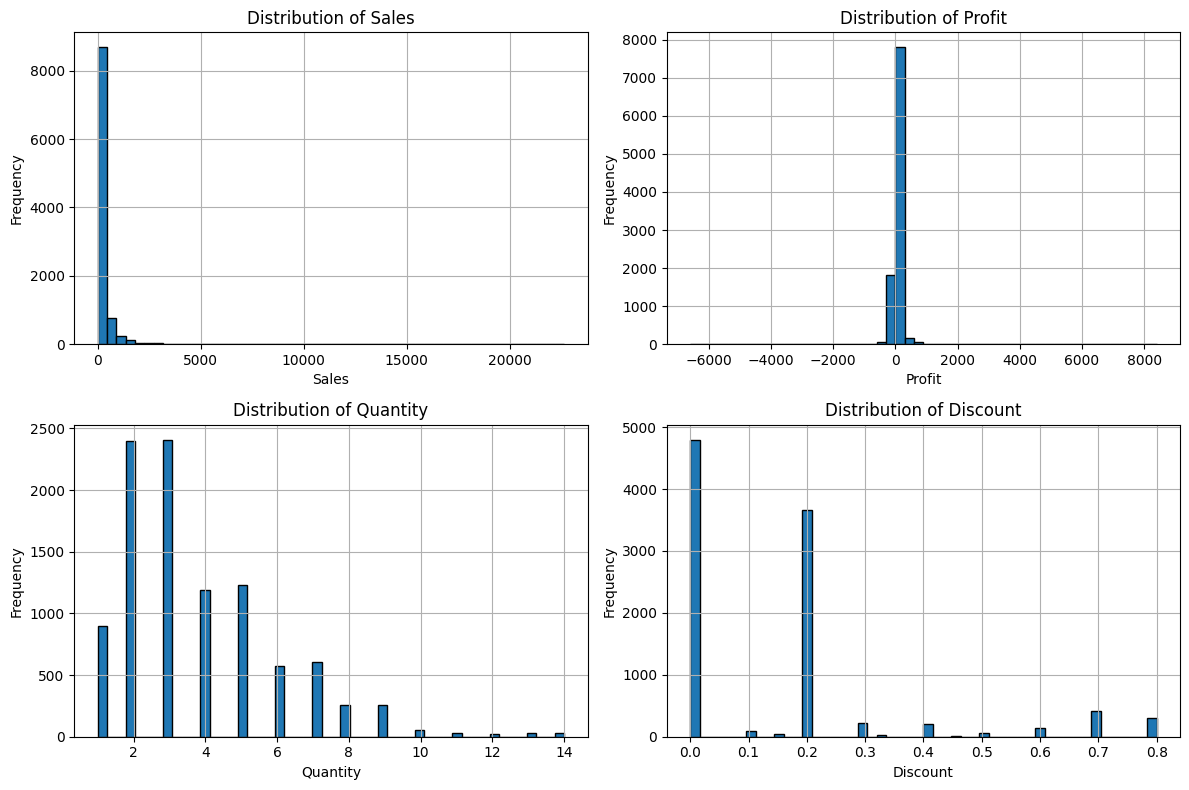

In [8]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=50, ax=axes[i], edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

- Sales and profit heavily skewed > might need log transformation later
- Negative profits > which products/region lose money?


Categorical columns

In [9]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Category:
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Sub-Category:
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

Region:
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


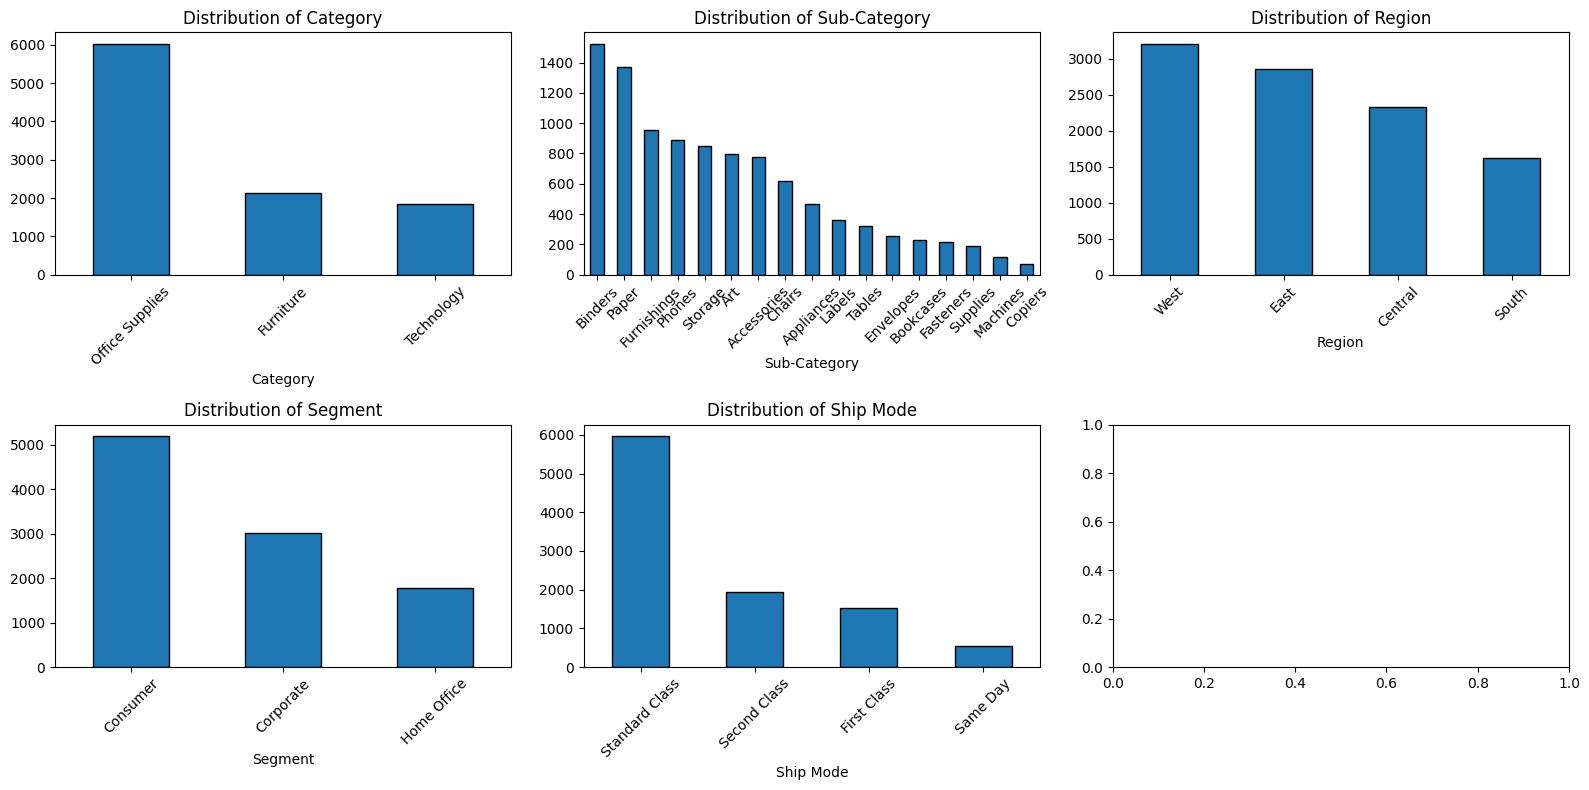

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i], edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

- REgion west most frequent
- mostly standard shipping
- mostly private consumers
- most office supplies

Date column

In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

print("First order: ", df["Order Date"].min()) 
print("Latest order: ", df["Order Date"].max())  # latest order

# Orders per year
df["Order Date"].dt.year.value_counts().sort_index()

First order:  2014-01-03 00:00:00
Latest order:  2017-12-30 00:00:00


Order Date
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64

- 3 years of data
- each year we get more orders

Text(0.5, 1.0, 'Correlation Matrix')

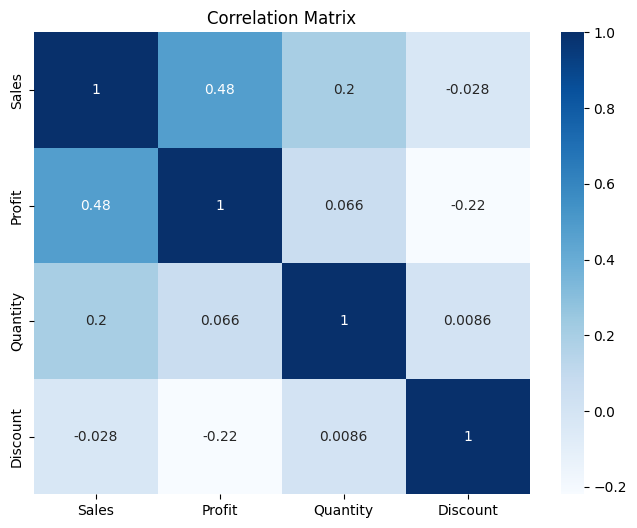

In [79]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")


Check outliers

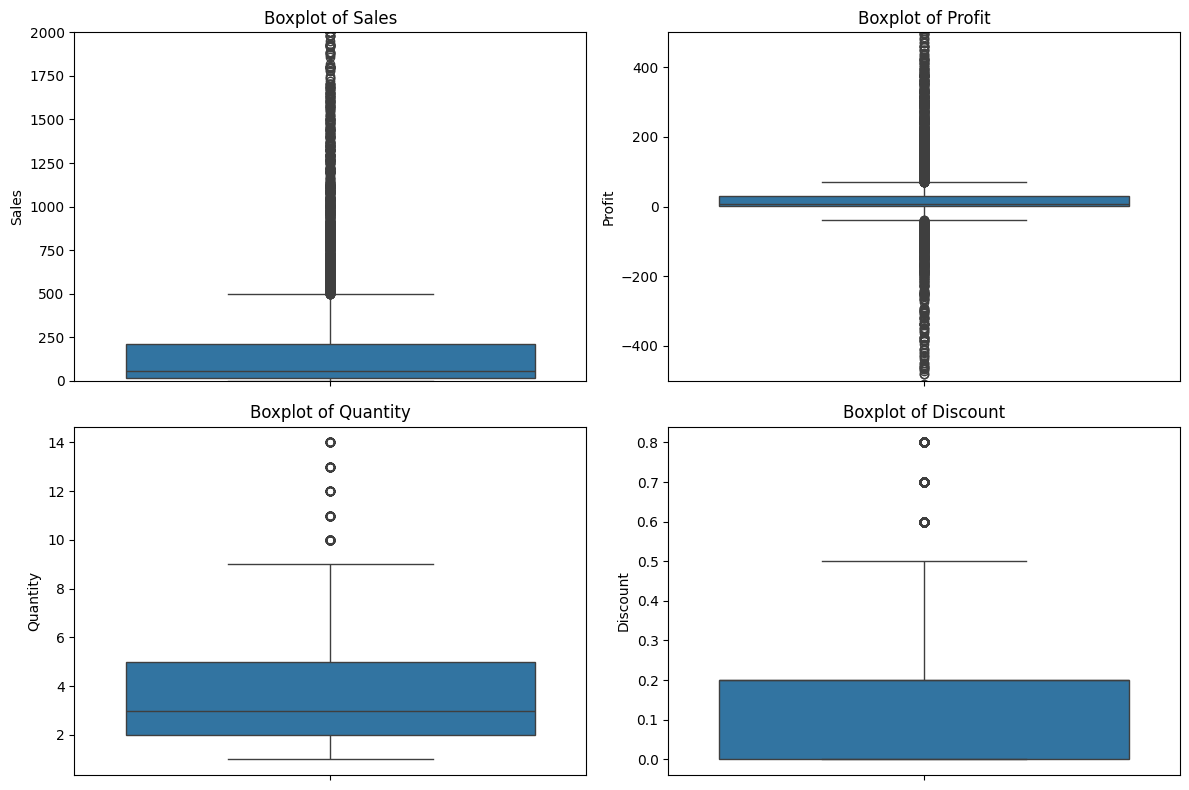

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

y_limits = {
    "Sales": (0, 2000),
    "Profit": (-500, 500),
    "Quantity": None,
    "Discount": None
}

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    if y_limits[col]:
        axes[i].set_ylim(y_limits[col])

plt.tight_layout()
plt.show()

Geographical analysis
- Region by category

Text(0, 0.5, 'Number of orders')

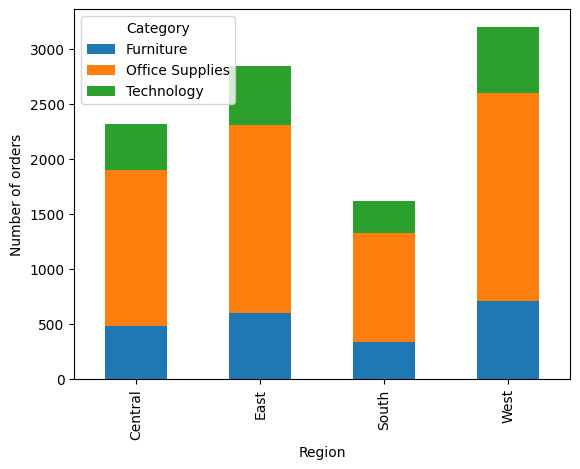

In [13]:
pd.crosstab(df["Region"], df["Category"]).plot(kind="bar", stacked=True)
plt.ylabel("Number of orders")


Which region is most profitable?

<Axes: xlabel='Region', ylabel='Profit'>

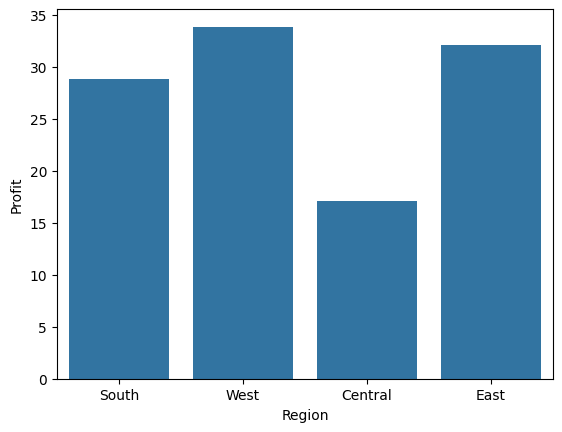

In [14]:
sns.barplot(x=df["Region"], y=df["Profit"], errorbar=None)

Which category has the worst margins?

<Axes: xlabel='Category', ylabel='Profit'>

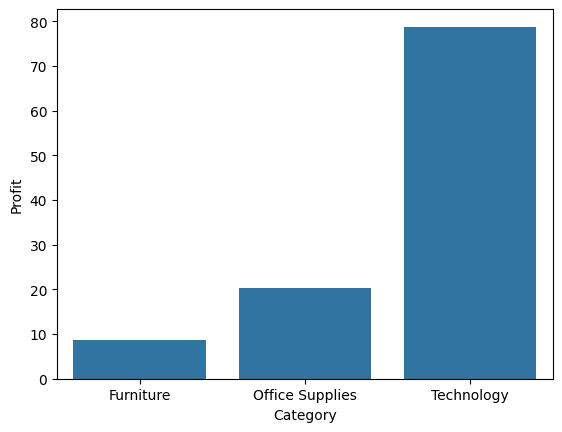

In [15]:
sns.barplot(x=df["Category"], y=df["Profit"], errorbar=None)

Time series

Sales over time

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\2035925335.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample("M", on="Order Date")["Sales"].sum()


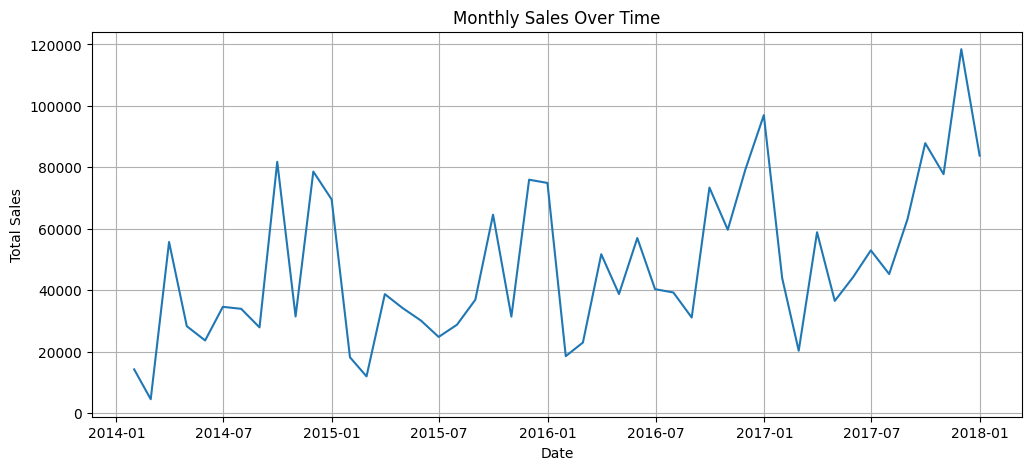

In [16]:
df = df.sort_values("Order Date")

monthly_sales = df.resample("M", on="Order Date")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)

Profit over time

C:\Users\marle\AppData\Local\Temp\ipykernel_24888\4275089560.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_profit = df.resample("M", on="Order Date")["Profit"].sum()


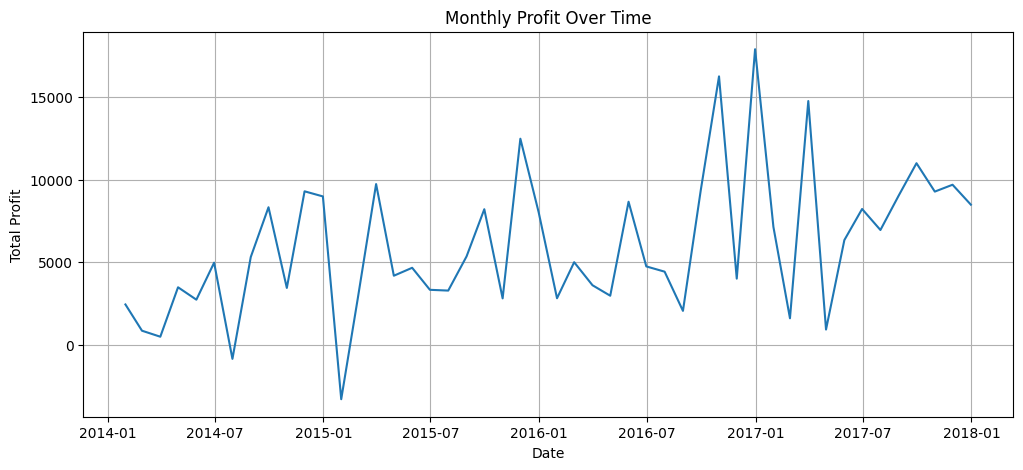

In [17]:
monthly_profit = df.resample("M", on="Order Date")["Profit"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_profit.index, monthly_profit.values)
plt.title("Monthly Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Total Profit")
plt.grid(True)

Seasonality

In [18]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

monthly = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()


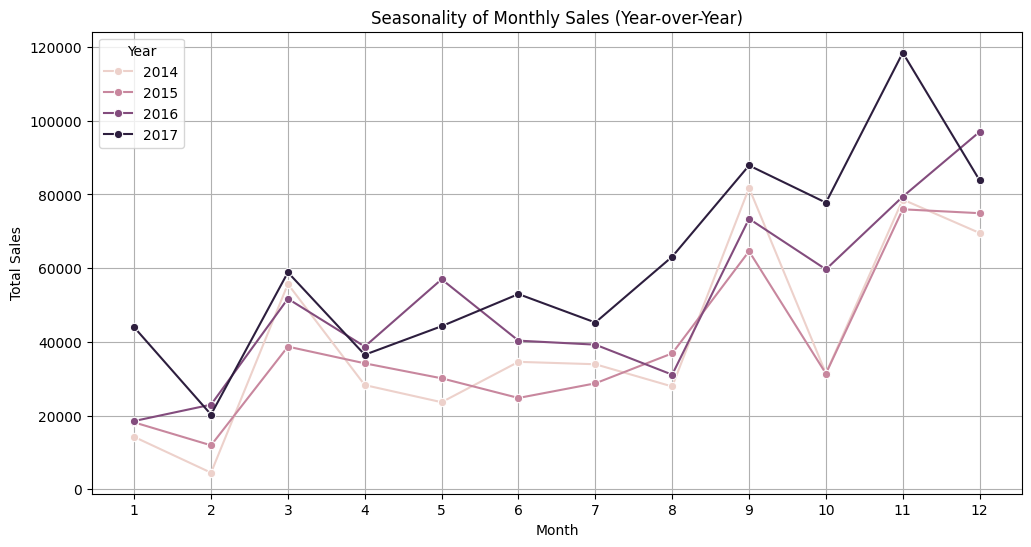

In [19]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Seasonality of Monthly Sales (Year-over-Year)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


Most profitable and least profitable products

<Axes: xlabel='Profit', ylabel='Sub-Category'>

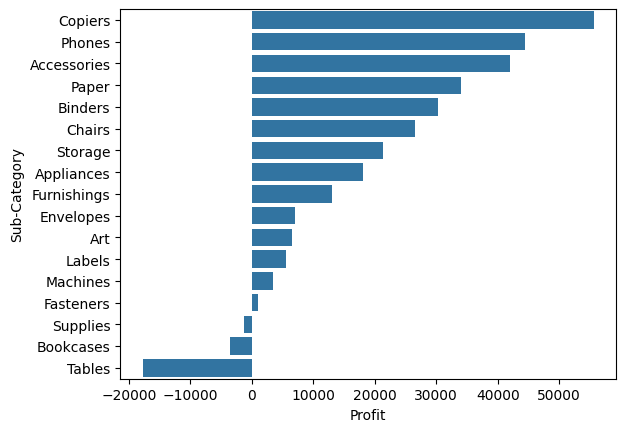

In [20]:
sub_cat = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .reset_index()
      .sort_values("Profit", ascending=False)
)

sns.barplot(
    data=sub_cat,
    x="Profit",
    y="Sub-Category",
    errorbar=None
)


Products that have a negative profit (espcially in comparison to high sales)

In [30]:
neg_profit = (df.groupby("Sub-Category")["Profit"].sum().reset_index())
neg_profit = neg_profit[neg_profit["Profit"]<0]

In [31]:
neg_profit.head(20)

,Sub-Category,Profit
4,Bookcases,-3472.5560
15,Supplies,-1189.0995
16,Tables,-17725.4811


Profit margin = Profit/sale
per category or per row?

In [33]:
df["profit_margin"] = df["Profit"] / df["Sales"]

<Axes: xlabel='Category', ylabel='profit_margin'>

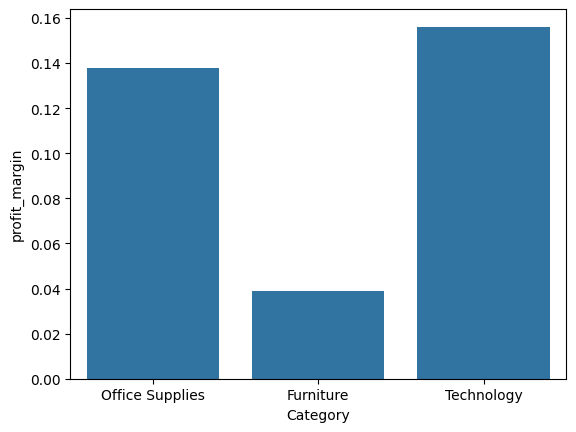

In [36]:
sns.barplot(x=df["Category"], y=df["profit_margin"], errorbar=None)

Discount vs Profit relationship

<Axes: xlabel='Discount', ylabel='Profit'>

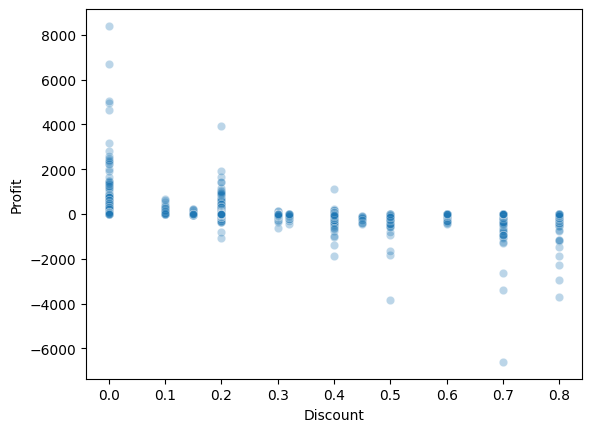

In [22]:
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.3)


Custoemr segmenation

Sale by segement

<Axes: xlabel='Segment', ylabel='Sales'>

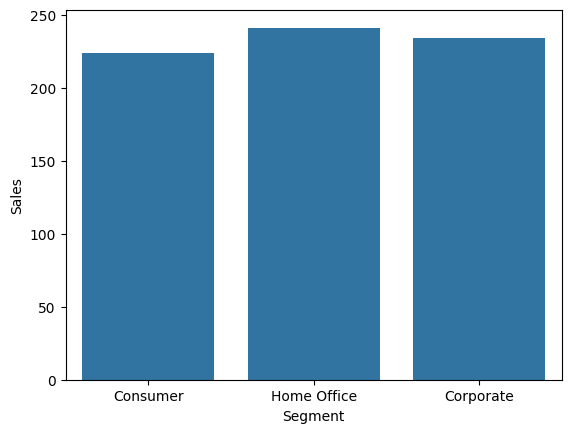

In [37]:
sns.barplot(x=df["Segment"], y=df["Sales"], errorbar=None)

Profit by Segment

<Axes: xlabel='Segment', ylabel='Profit'>

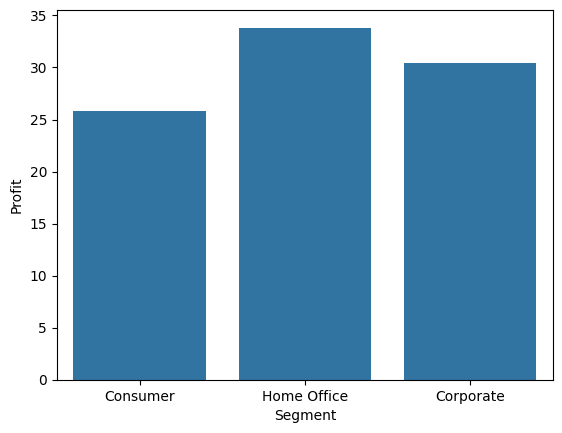

In [38]:
sns.barplot(x=df["Segment"], y=df["Profit"], errorbar=None)

Average order value

In [45]:
avg_order_value = (df.groupby("Order ID")["Sales"].sum().reset_index())
avg = np.average(avg_order_value["Sales"]).round(2)
print(f"The average sale per order is {avg}.")

The average sale per order is 458.61.


Average order value per segment

In [56]:
order_value= (df.groupby("Order ID")["Sales"].sum().reset_index().rename(columns={"Sales": "OrderValue"}))
segment_map = df.groupby("Order ID")["Segment"].first().reset_index()

order_value_seg = order_value.merge(segment_map, on = "Order ID")

avg_seg = (order_value_seg.groupby("Segment")["OrderValue"].mean().reset_index())
avg_seg

,Segment,OrderValue
0,Consumer,449.111116
1,Corporate,466.411075
2,Home Office,472.665730


In [58]:
segment_map

,Order ID,Segment
0,CA-2014-100006,Consumer
1,CA-2014-100090,Corporate
2,CA-2014-100293,Home Office
3,CA-2014-100328,Consumer
4,CA-2014-100363,Corporate
...,...,...
5004,US-2017-168802,Corporate
5005,US-2017-169320,Consumer
5006,US-2017-169488,Consumer
5007,US-2017-169502,Home Office


<Axes: xlabel='Segment', ylabel='OrderValue'>

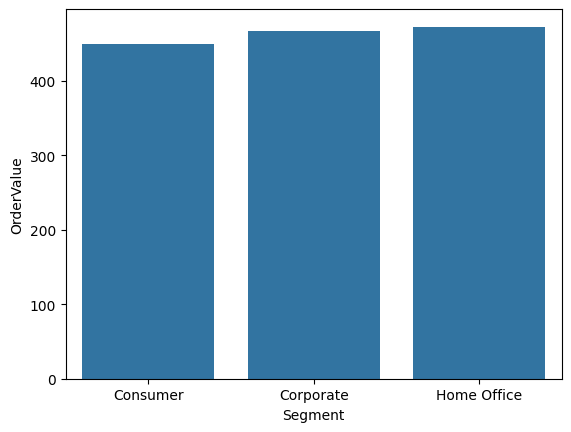

In [57]:
sns.barplot(x=avg_seg["Segment"], y=avg_seg["OrderValue"], errorbar=None)

Number of orders per customer

In [76]:
#Map order ID to customer ID

customer_map = df.groupby("Order ID")["Customer ID"].first().reset_index()

# group by customer ID and count order ID distinct

orders_per_customer = (
    customer_map.groupby("Customer ID")["Order ID"]
    .count().rename("Number_of_Orders")
)

avg_order_customer = orders_per_customer.mean().round(2)

print(f"The average number of order is {avg_order_customer}")

The average number of order is 6.32
